# Additional Analyses

In addition to the dotplot, we have provided a few additional functions for assessing your KSTAR results, as well as the underlying networks that gave rise to them. Here, still using the example of TCR activation, we have provided some examples on how to use these functions.

If there are any functions/analysis that are not discussed here that you would like to see in the future, please add a feature request at [KSTAR's github repository](https://github.com/NaegleLab/KSTAR).

## Load results and other necessary data (networks, binary evidence, etc.)

In [ ]:
#import necessary packages
from kstar import calculate

odir = './example'
name = 'example_run'

#Load kstar_slim save
kinact_dict = calculate.from_kstar(name, odir)

phospho_type = 'Y' #running on this type of kinase/substrate network

#load binarized experiment and networks from KinaseActivity object
binary_evidence = kinact_dict['Y'].evidence_binary.copy()
networks = kinact_dict['Y'].networks

## Identify relevant phosphorylation sites for a kinase of interest

In some cases, you may want to know what phosphorylation sites an active kinase is interacting with to get a clearer picture of the specific kinase-substrate interactions taking place. Using the analysis.interactions module, you can identify the phosphorylation sites that are contributing most to the activity prediction (based on the number of networks for which the observed site is connected to the kinase of interest). For our TCR activation example, we observed that LCK is highly activated upon activation. We would like to know what substrates LCK is mostly interacting with.

*Important note to keep in mind: KSTAR networks contain predictions and are not guaranteed to be true interactions. Just because it appears in one of the networks does not mean it is a true interaction*

In [2]:
from kstar.analysis import interactions

In [3]:
experiment_influence = interactions.getSubstrateInfluence_inExperiment(networks, binary_evidence, 'LCK')

The above function produces a dictionary with each data column/sample as a key. For each sample, a pandas series object is generated which indicates potential substrates of the kinase of interest that were identified as evidence for the given sample, as well as the number of different networks that kinase-substrate interaction is found in. The more networks an interaction is found, the higher likelihood of it being a true interaction and the stronger its influence on the final predictions. Only sites found in the given sample AND have at least one interaction across the 50 networks will appear in these results. Known substrates will be found across most, if not all, networks (to check if a site is a known substrate, we often go to [PhosphoSitePlus](https://www.phosphosite.org/homeAction.action))

In [4]:
experiment_influence['data:time:15'].iloc[0:10]

Q08881_Y240     50.0
Q08881_Y273     50.0
P43403_Y198     50.0
P43403_Y204     50.0
P43403_Y597     50.0
P15498_Y791     50.0
P09693_Y171     48.0
P09693_Y160     46.0
Q00610_Y1237    40.0
Q8IZP0_Y484     39.0
Name: Number of Networks connected to LCK, dtype: float64

We can see that LCK is likely responsible for phosphorylating sites on ITK (Q08881), ZAP70 (P43403), and VAV (P15498), among others. This makes sense based on what is known about TCR signaling.

## Exploring Network and Experiment Coverage of Phosphorylation Sites

In addition to digging deeper into the KSTAR results, you may want to better understand the networks that went into prediction (and how they might compare to other kinase-substrate networks). The below approaches are designed for such analysis.

### Number of unique phosphorylation sites in network(s)

You may be interested to know how many phosphorylation sites are actually contained within a network. To check, run the following function:

In [5]:
from kstar.analysis import coverage

In [9]:
coverage.numUniqueSubstrates(networks['0'])

34962

The above value is for only a single pruned network. What about across all 50 pruned networks? 

In [11]:
coverage.numUniqueSubstrates(networks)

39242

You'll see that the overall coverage of the phosphoproteome is higher across all 50 networks than when using only a single network, just one of the advantages of the ensemble approach used in KSTAR. We can also ask the average number of sites covered within each individual network:

In [24]:
coverage.averageUniqueSubstrates_KSTAR(networks=networks)

{'all': np.float64(35017.7)}

### Distribution of Study Bias in Phosphoproteome and in Experiments

One of the major challenges KSTAR was designed tackle is the prevalance of study bias towards certain phosphorylation sites within networks and experiments. You can see the distribution of study bias within your experiment, and compare it to the distribution seen across the entire phosphoproteome.

In [16]:
from kstar.analysis import coverage

Text(0.5, 1.0, 'In Single Sample')

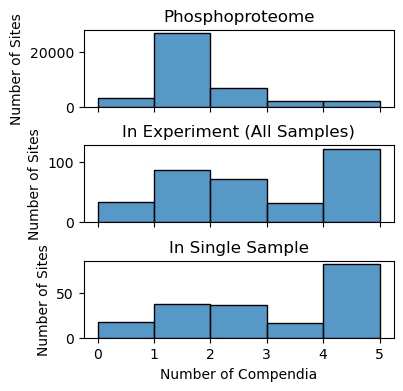

In [ ]:
fig, axes = plt.subplots(figsize = (4,4),nrows = 3, sharex = 'all')
fig.subplots_adjust(hspace = 0.5)
#study bias in reference phosphoproteome
coverage.getStudyBiasDistribution_InPhosphoproteome(ax = axes[0])
axes[0].set_title('Phosphoproteome')
#study bias across all sites in experiment file
coverage.getStudyBiasDistribution_InExperiment(kinact_dict['Y'].evidence_binary, ax = axes[1])
axes[1].set_title('In Experiment (All Samples)')
#study bias in single column of experiment file
coverage.getStudyBiasDistribution_InSample(kinact_dict['Y'].evidence_binary, data_column = 'data:time:30', ax = axes[2])
axes[2].set_title('In Single Sample')

As described in the KSTAR publication, we see that the phosphoproteomic experiment contains a much higher proportion of well-studied sites than the overall phosphoproteome. 

### Coverage of Experiment by Kinase-Substrate Network

Another challenge of many kinase activity prediction approaches, particularly those relying on PhosphoSitePlus annotations, is that only a small percentage of sites can actually be used for activity prediction due to unknown kinase interactions. To get an idea of how many phosphorylation sites observed in an experiment will actually be used in prediction, you can use the below functions, either for a single network (passing a pandas dataframe) or an ensemble of networks (passing a dictionary of pandas dataframes):

In [11]:
from kstar.analysis import coverage

In [22]:
coverage.experimentCoverage(kinact_dict['Y'].evidence_binary, networks['0'])

0.8483965014577259

In [23]:
coverage.experimentCoverage(kinact_dict['Y'].evidence_binary, networks)

0.9883381924198251

We have almost complete coverage of our phosphoproteomic dataset when using all 50 pruned networks, meaning that almost every observed phosphorylation site is contributing to prediction.

### Similarity between kinases in network

Lastly, kinase-substrate prediction networks often suffer from a high degree of similarity between kinases from the same family. We can look at the mutual information shared between kinases within a network (or ensemble of networks), or the fraction of shared substrates. We can then plot this as heatmap:

In [25]:
from kstar.analysis import kinase_MI

In [26]:
num_shared_substrates, mutual_info, overlapping_substrates = kinase_MI.kinase_mutual_information(networks)

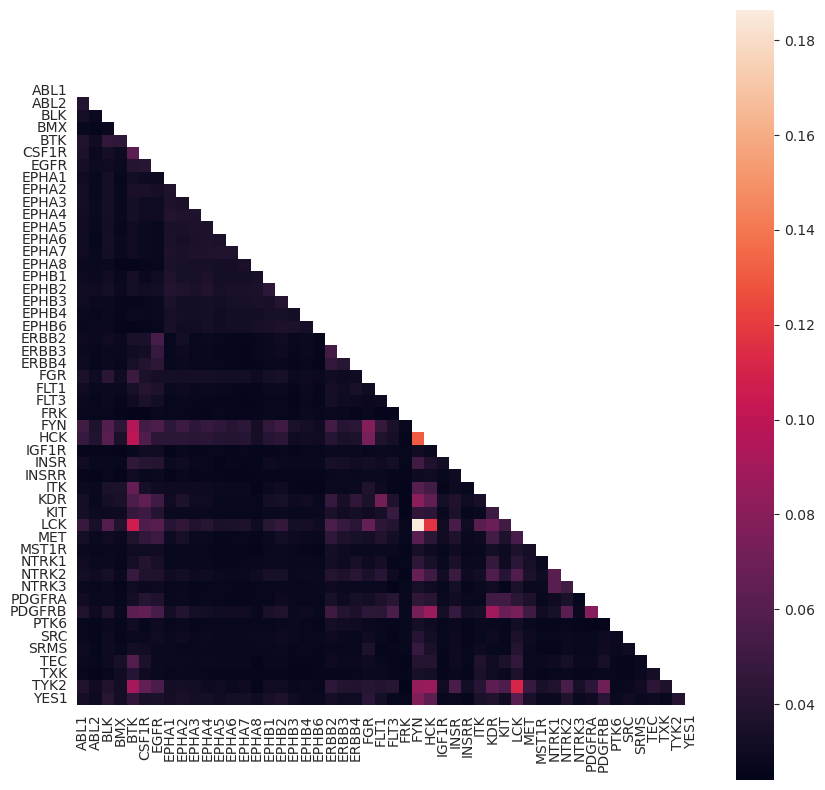

In [16]:
plt.figure(figsize = (10,10))
kinase_MI.plot_kinase_heatmap(mutual_info, annotate = False)